In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# -----------------------
# 1. 데이터 로드
# -----------------------
data = load_wine()
x = data.data
y = data.target  # 0,1,2
print(x.shape)
print(x)
print(y.shape)
print(y)
# -----------------------
# 2. 데이터 분리
# -----------------------
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# -----------------------
# 3. 정규화
# -----------------------
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# -----------------------
# 4. 모델 (softmax🔥)
# -----------------------
# 🎯 한 줄 핵심

# 👉 input_dim = 1차원 전용 (Dense에서만 간단하게 쓰는 것)
# 👉 input_shape = 모든 레이어에서 쓰는 정식 표현 (튜플)
# Dense(32, input_dim=13)
# 입력 feature 개수 = 13
# 👉 내부적으로 이렇게 변환됨:

# input_shape = (13,)
# | 상황          | 추천             |
# | ----------- | -------------- |
# | Dense 간단 예제 | input_dim      |
# | 일반적인 코드     | input_shape    |
# | CNN / RNN   | input_shape 필수 |
# 🔥 3. 중요한 이유 (진짜 핵심)
# ✔ input_shape는 확장 가능

# 예:

# # 이미지
# input_shape = (28, 28, 1)

# # 시계열
# input_shape = (10, 5)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(x.shape[1],)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')  # 핵심🔥
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------
# 5. 학습
# -----------------------
history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=100,
    verbose=0
)

(178, 13)
[[1.423e+01 1.710e+00 2.430e+00 ... 1.040e+00 3.920e+00 1.065e+03]
 [1.320e+01 1.780e+00 2.140e+00 ... 1.050e+00 3.400e+00 1.050e+03]
 [1.316e+01 2.360e+00 2.670e+00 ... 1.030e+00 3.170e+00 1.185e+03]
 ...
 [1.327e+01 4.280e+00 2.260e+00 ... 5.900e-01 1.560e+00 8.350e+02]
 [1.317e+01 2.590e+00 2.370e+00 ... 6.000e-01 1.620e+00 8.400e+02]
 [1.413e+01 4.100e+00 2.740e+00 ... 6.100e-01 1.600e+00 5.600e+02]]
(178,)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


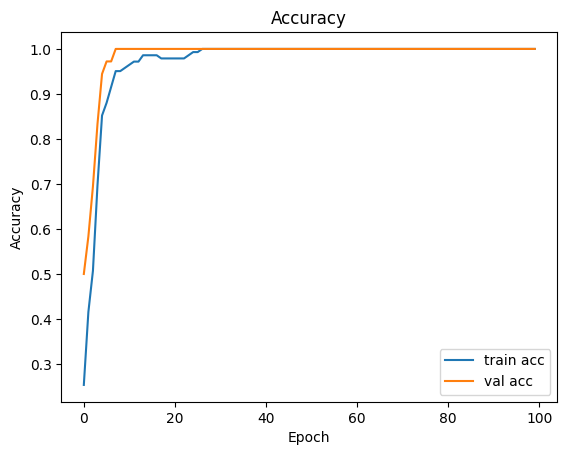

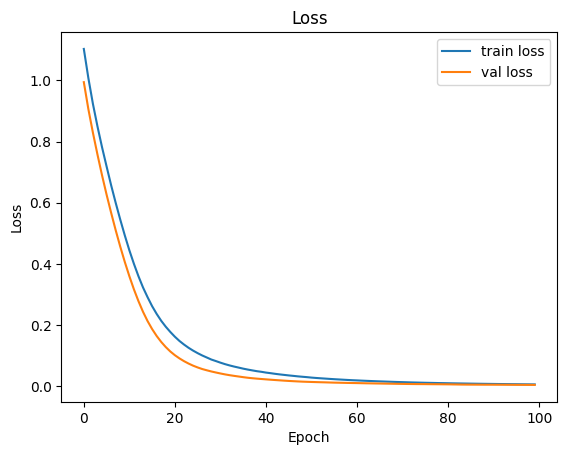

In [2]:
# 📊 2. 정확도 + loss 그래프 (과적합 확인)
plt.figure()

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()
plt.show()


plt.figure()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


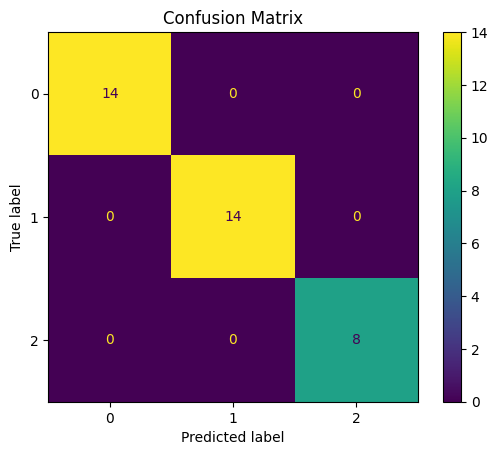

In [3]:
#📊 3. 혼동행렬 (성능 시각화🔥)
y_pred = model.predict(x_test)
y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# 🎯 시험 문제 세트 (Softmax 다중분류 – Wine dataset)

---

## 📝 문제 1 (개념)

다음 중 **softmax 함수에 대한 설명으로 옳은 것**을 모두 고르시오.

```
① 각 뉴런에 독립적으로 적용된다  
② 출력값의 합은 1이다  
③ 확률로 해석할 수 있다  
④ sigmoid와 동일하게 동작한다  
```

### ✅ 정답

```
②, ③
```

---

## 📝 문제 2 (손실함수)

다음 조건에서 올바른 loss 함수를 고르시오.

* 클래스: 3개
* y 형태: [0, 1, 2]

```
① binary_crossentropy  
② categorical_crossentropy  
③ sparse_categorical_crossentropy  
④ mse  
```

### ✅ 정답

```
③
```

---

## 📝 문제 3 (모델 구조)

다음 코드에서 빈칸을 채우시오.

```python
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_dim=13),
    tf.keras.layers.Dense(____, activation='____')
])
```

### ✅ 정답

```python
3, 'softmax'
```

---

## 📝 문제 4 (코드 이해)

다음 코드의 의미를 설명하시오.

```python
y_pred = model.predict(x_test)
y_pred = np.argmax(y_pred, axis=1)
```

### ✅ 정답

* softmax 출력은 확률 벡터
* 가장 큰 값을 가지는 인덱스를 선택하여 클래스 결정

---

## 📝 문제 5 (그래프 해석 – 핵심🔥)

다음 상황에서 올바른 설명을 고르시오.

```
train accuracy: 계속 증가  
validation accuracy: 일정 시점 이후 감소  
```

### 보기

```
① 정상 학습  
② 과소적합  
③ 과적합  
④ 데이터 부족  
```

### ✅ 정답

```
③ 과적합
```

---

## 📝 문제 6 (코딩 문제)

다음 조건을 만족하는 Keras 모델을 작성하시오.

* 입력 feature: 13개
* hidden layer: 1개 (16 뉴런)
* 출력: 3개 클래스
* optimizer: adam
* loss: 올바른 다중분류 loss

### ✅ 정답 코드

```python
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(13,)),
    tf.keras.layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
```

---

## 📝 문제 7 (응용)

softmax 대신 sigmoid를 사용하면 어떤 문제가 발생하는가?

### ✅ 정답

* 클래스 간 경쟁이 없음
* 확률 합이 1이 아님
* 다중 분류 문제에 부적합

---

## 📝 문제 8 (심화🔥)

다음 중 과적합을 줄이는 방법을 모두 고르시오.

```
① Dropout  
② 데이터 증가  
③ epoch 증가  
④ 모델 단순화  
```

### ✅ 정답

```
①, ②, ④
```

---

## 🎯 보너스 (서술형)

다음을 설명하시오.

> “왜 softmax와 crossentropy를 함께 사용하는가?”

### ✅ 핵심 답

* 확률 분포를 출력
* log를 사용하여 오차를 안정적으로 계산
* gradient 계산이 효율적

---

## 🚀 한 줄 요약

👉 개념 + 코드 + 해석을 모두 평가할 수 있는 다중분류 종합 문제 세트
